## Setup

In [3]:
import sys
if 'google.colab' in sys.modules:
    print('Running in Google Colab')
    !pip install -q py4DSTEM hyperspy scikit-image matplotlib numpy scipy tensorflow tqdm
    !git clone -q https://github.com/NU-MSE-LECTURES/465-WINTER2026.git
    import os
    os.chdir('/content/465-WINTER2026')
    print('Colab setup complete!')
else:
    print('Running in local environment')

Running in local environment


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from skimage import exposure, filters, measure, morphology, segmentation
from skimage.io import imread
from skimage.feature import canny, local_binary_pattern
from scipy import ndimage

from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, silhouette_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('All imports successful!')
print(f'TensorFlow version: {tf.__version__}')

All imports successful!
TensorFlow version: 2.11.0


## Task 1 · Classical Image Analysis Pipeline
- [ ] Apply noise reduction (Gaussian, median, or FFT filtering) and compute signal-to-noise ratio before and after using $SNR = u / igma$.
- [ ] Enhance contrast via histogram equalization or CLAHE (clip limit 0.01-0.03).
- [ ] Segment features using Otsu thresholding followed by Watershed to separate touching particles.
- [ ] Quantify morphology with `regionprops` (area, diameter, eccentricity, solidity) and export measurements to `classical_results.csv`.
- [ ] Create a four-panel figure: raw image, filtered/enhanced result, segmented labels, particle size distribution.

In [5]:
# Task 1 — Load a subset of DOPAD images
root = Path.cwd().resolve()
candidates = [
    root / "raw_data",
    root / "Week_04" / "assignments" / "raw_data",
    Path("Week_04/assignments/raw_data").resolve(),
]

IMAGE_DIR = next((p for p in candidates if p.is_dir()), None)
if IMAGE_DIR is None:
    raise FileNotFoundError(f"raw_data folder not found. Tried: {candidates}")

OUTPUT_DIR = root

n_samples = 100
image_files = sorted(IMAGE_DIR.glob("*.png"))[:n_samples]

print(f"Notebook dir: {root}")
print(f"Using IMAGE_DIR: {IMAGE_DIR} (exists={IMAGE_DIR.exists()})")
print(f"Loaded {len(image_files)} PNG images (n_samples={n_samples})")

Notebook dir: /Users/kylexu/Desktop/matsci465_project/HW3&4
Using IMAGE_DIR: /Users/kylexu/Desktop/matsci465_project/HW3&4/raw_data (exists=True)
Loaded 100 PNG images (n_samples=100)


In [6]:
# Load one image + basic preprocessing (grayscale, float in [0,1])
img_path = image_files[0]
raw = imread(str(img_path))

# drop alpha / convert to grayscale if multi-channel
raw_image = raw[..., 0] if raw.ndim == 3 else raw

# scale to [0, 1] robustly
raw_image = raw_image.astype(np.float32)
if raw_image.max() > 1.0:
    raw_image /= 255.0

print(f"Loaded: {img_path.name}")
print(f"shape={raw_image.shape}, dtype={raw_image.dtype}, min/max={raw_image.min():.4f}/{raw_image.max():.4f}")

Loaded: 11500X00.png
shape=(416, 416), dtype=float32, min/max=0.0000/1.0000


SNR before filtering: 4.8529
SNR after Gaussian filtering: 4.8994
SNR after Median filtering: 4.8865
SNR after Light Gaussian filtering: 4.8707
SNR μ/σ over 20 imgs | before: 4.9201 ± 0.4343 | after: 4.9436 ± 0.4394
Enhanced image range: [0.000, 1.000]
Otsu threshold: 0.6582
Number of particles detected: 688
Saved: /Users/kylexu/Desktop/matsci465_project/HW3&4/classical_results.csv  (n=688)
Saved: /Users/kylexu/Desktop/matsci465_project/HW3&4/classical_pipeline_figure.png


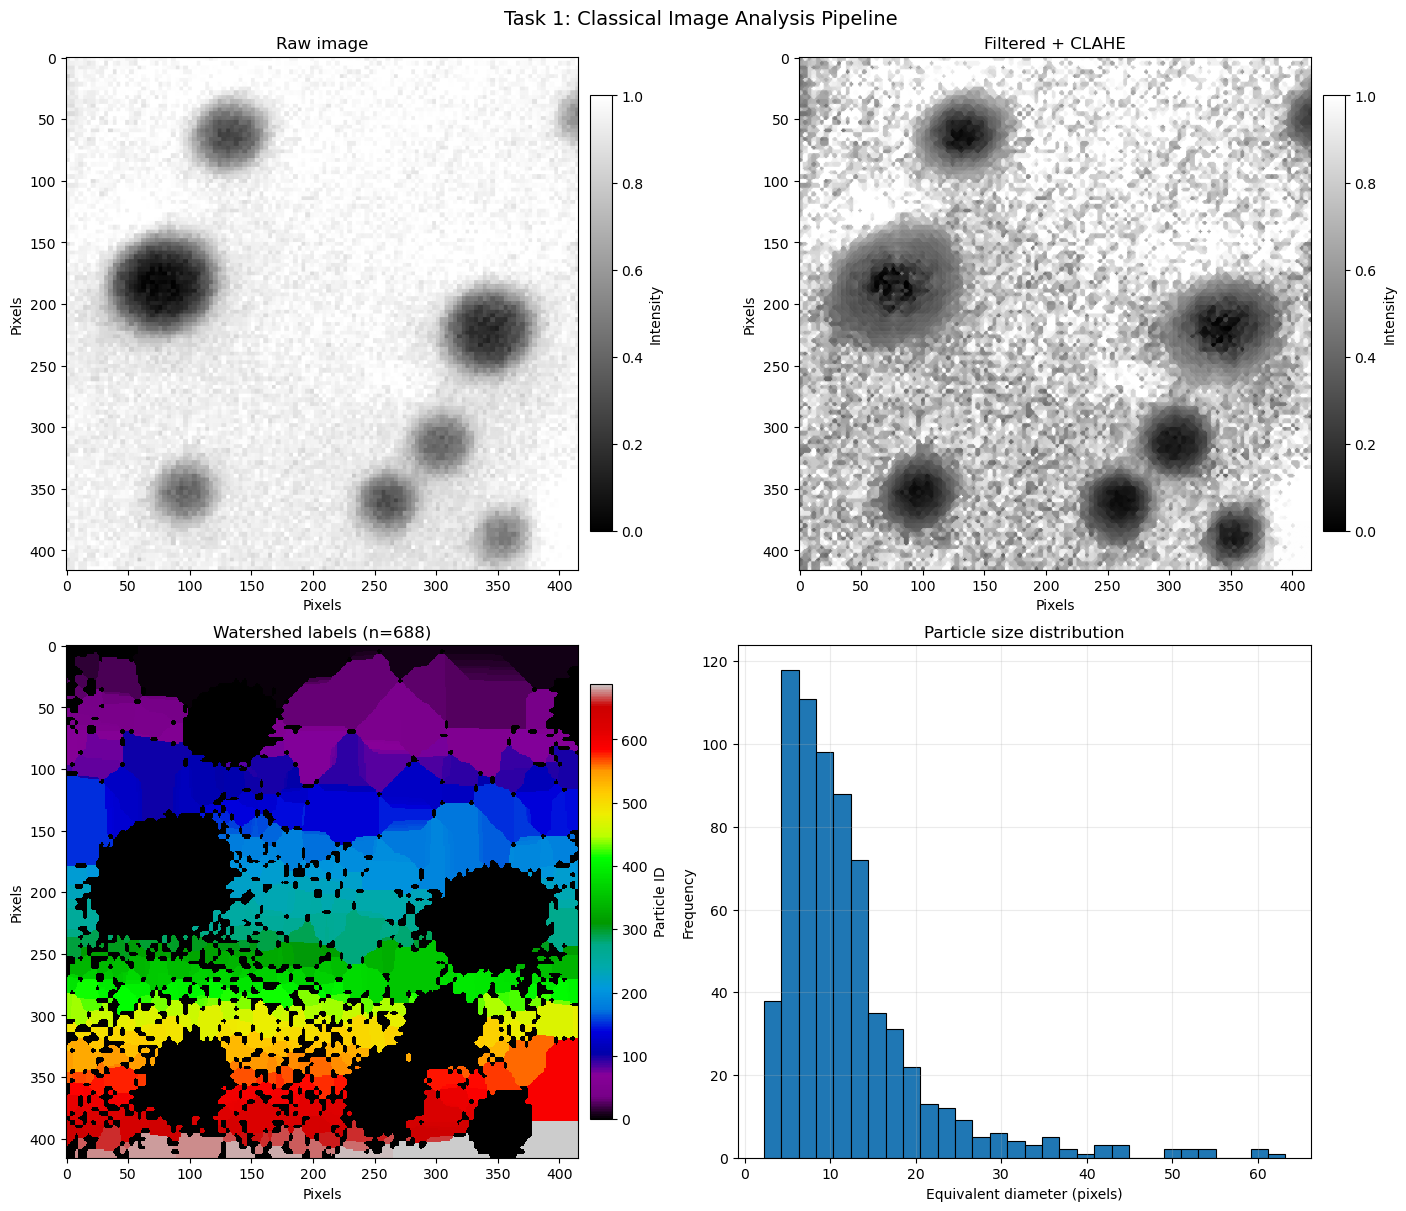

In [7]:
# Task 1 processing: filtering, enhancement, segmentation, quantification
# HINTS for Task 1:
# 1. Filtering: Use filters.median() or filters.gaussian() from skimage.filters
#    Compare SNR before and after filtering to see improvement
# 2. Enhancement: Use exposure.equalize_adapthist() with clip_limit around 0.025
#    This will increase contrast without oversaturation
# 3. Segmentation: After Otsu thresholding, use scipy.ndimage.distance_transform_edt()
#    to find marker positions for Watershed
# 4. Regionprops: Pass intensity_image parameter to get min/max/mean intensity
#    Example: measure.regionprops(labels, intensity_image=enhanced_image)
# 5. Export: Use pd.DataFrame.to_csv() to save measurements

def compute_snr(image: np.ndarray) -> float:
    signal = np.mean(image)
    noise = np.std(image)
    return float(signal / noise) if noise else np.inf

# Filtering hint: Try median filter for salt-and-pepper noise
filtered_image = filters.median(raw_image, footprint=morphology.disk(3))
k = min(20, len(image_files))
snr0, snr1 = [], []
for p in image_files[:k]:
    im = imread(str(p))
    im = im[..., 0] if im.ndim == 3 else im
    im = im.astype(np.float32)
    if im.max() > 1.0:
        im /= 255.0
    snr0.append(compute_snr(im))
    snr1.append(compute_snr(filters.median(im, footprint=morphology.disk(2))))
    
snr_before = compute_snr(raw_image)
snr_gauss  = compute_snr(filters.gaussian(raw_image, sigma=1.0))
snr_med    = compute_snr(filtered_image)  # your median result
snr_light  = compute_snr(filters.gaussian(raw_image, sigma=0.5))

print(f"SNR before filtering: {snr_before:.4f}")
print(f"SNR after Gaussian filtering: {snr_gauss:.4f}")
print(f"SNR after Median filtering: {snr_med:.4f}")
print(f"SNR after Light Gaussian filtering: {snr_light:.4f}")

print(f"SNR μ/σ over {k} imgs | before: {np.mean(snr0):.4f} ± {np.std(snr0):.4f} | after: {np.mean(snr1):.4f} ± {np.std(snr1):.4f}")

# Enhancement hint: CLAHE improves local contrast
# enhanced_image = exposure.equalize_adapthist(filtered_image, clip_limit=0.025)
filtered_image = filters.median(raw_image, footprint=morphology.disk(2))
enhanced_image = exposure.equalize_adapthist(filtered_image, clip_limit=0.025)
print(f"Enhanced image range: [{enhanced_image.min():.3f}, {enhanced_image.max():.3f}]")

# Segmentation hint: Use Otsu's threshold followed by watershed
# threshold = filters.threshold_otsu(enhanced_image)
# binary = enhanced_image > threshold
# Then use distance transform + watershed to separate particles
thr = filters.threshold_otsu(enhanced_image)
mask = enhanced_image > thr
mask = morphology.remove_small_objects(mask, min_size=10)
mask = morphology.remove_small_holes(mask, area_threshold=10)

dist = ndimage.distance_transform_edt(mask)

peak_mask = morphology.local_maxima(dist)
markers, _ = ndimage.label(peak_mask)

labels = segmentation.watershed(-dist, markers=markers, mask=mask)

print(f"Otsu threshold: {thr:.4f}")
print(f"Number of particles detected: {int(labels.max())}")

# Morphology hint: Extract area, perimeter, eccentricity, solidity, equivalent_diameter
# Store in a DataFrame, then save with measurements.to_csv()
props = measure.regionprops_table(
    labels,
    intensity_image=enhanced_image,
    properties=("label", "area", "perimeter", "eccentricity", "solidity", "equivalent_diameter", "centroid",
                "intensity_min", "intensity_mean", "intensity_max"),
)
measurements = pd.DataFrame(props)
measurements.to_csv(OUTPUT_DIR / "classical_results.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'classical_results.csv'}  (n={len(measurements)})")

# Visualization hint: Create 2x2 subplot figure with:
# [Raw image] [Enhanced/Filtered]
# [Segmented labels] [Size distribution histogram]
# Use imshow() for images and hist() for distribution
fig, ax = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)

im_raw = ax[0, 0].imshow(raw_image, cmap="gray", vmin=0, vmax=1)
ax[0, 0].set_title("Raw image")
ax[0, 0].set_xlabel("Pixels"); ax[0, 0].set_ylabel("Pixels")
fig.colorbar(im_raw, ax=ax[0, 0], shrink=0.85, pad=0.02, label="Intensity")

im_enh = ax[0, 1].imshow(enhanced_image, cmap="gray", vmin=0, vmax=1)
ax[0, 1].set_title("Filtered + CLAHE")
ax[0, 1].set_xlabel("Pixels"); ax[0, 1].set_ylabel("Pixels")
fig.colorbar(im_enh, ax=ax[0, 1], shrink=0.85, pad=0.02, label="Intensity")

im_lab = ax[1, 0].imshow(labels, cmap="nipy_spectral", interpolation="nearest")
ax[1, 0].set_title(f"Watershed labels (n={int(labels.max())})")
ax[1, 0].set_xlabel("Pixels"); ax[1, 0].set_ylabel("Pixels")
fig.colorbar(im_lab, ax=ax[1, 0], shrink=0.85, pad=0.02, label="Particle ID")

vals = measurements["equivalent_diameter"].to_numpy()
ax[1, 1].hist(vals, bins=30, edgecolor="black", linewidth=0.8)
ax[1, 1].set_title("Particle size distribution")
ax[1, 1].set_xlabel("Equivalent diameter (pixels)")
ax[1, 1].set_ylabel("Frequency")
ax[1, 1].grid(True, alpha=0.25)

fig.suptitle("Task 1: Classical Image Analysis Pipeline", fontsize=14)

fig_path = OUTPUT_DIR / "classical_pipeline_figure.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

## Task 2 · Machine Learning Approaches
- [ ] Extract hand-crafted features: edges (Canny or Sobel), blobs (LoG), textures (LBP or GLCM) to build a feature matrix with at least 10 descriptors per region.
- [ ] Perform feature selection using Random Forest importance or correlation analysis; retain the top 5-7 discriminative features.
- [ ] Supervised: label data into two or more classes (≥50 samples), train SVM and Random Forest, then report precision, recall, F1-score, and confusion matrices.
- [ ] Unsupervised: run k-Means (k ∈ {3, 5, 7}) and visualize using PCA or t-SNE; compute silhouette scores.
- [ ] Compare ML outputs with classical segmentation regarding particle counts, accuracy, and runtime; export to `ml_results.csv`.

In [8]:
# Task 2: feature extraction and ML pipelines
from skimage.feature import canny, local_binary_pattern
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [9]:
# HINTS for Task 2:
# 1. Feature extraction: For each detected region, compute:
#    - Area, perimeter, equivalent diameter, eccentricity, solidity (from regionprops)
#    - Mean and std intensity (intensity-based features)
#    - Edge features: number of edges detected by Canny filter
#    - Texture: Local Binary Pattern variance
#    - Circularity = 4*pi*area / perimeter^2
#    - Total: 10+ features per region

def extract_region_features(region, image):
    """Return 10+ hand-crafted descriptors for one labeled region."""
    rr, cc = region.coords[:, 0], region.coords[:, 1]

    # intensity values inside the region
    vals = image[rr, cc].astype(np.float32)

    # precompute feature images locally (fast + avoids bbox slicing)
    edges = canny(image, sigma=1.0)
    lbp = local_binary_pattern((image * 255).astype(np.uint8), P=8, R=1, method="uniform")

    area = float(region.area)
    per = float(region.perimeter)
    circ = (4.0 * np.pi * area / (per * per)) if per > 0 else np.nan
    comp = ((per * per) / area) if area > 0 else np.nan

    edge_count = float(edges[rr, cc].sum())
    edge_frac = (edge_count / area) if area > 0 else np.nan
    lbp_var = float(np.var(lbp[rr, cc])) if area > 0 else np.nan

    return {
        "area": area,
        "perimeter": per,
        "equiv_diameter": float(region.equivalent_diameter),
        "eccentricity": float(region.eccentricity),
        "solidity": float(region.solidity),
        "mean_intensity": float(vals.mean()),
        "std_intensity": float(vals.std(ddof=0)),
        "edge_count": edge_count,
        "edge_fraction": edge_frac,
        "lbp_variance": lbp_var,
        "circularity": circ,
        "compactness": comp,
    }

# Extract Features
n_imgs = min(50, len(image_files))
rows = []

print(f"Extracting region features from {n_imgs} images...")
for img_i, p in enumerate(tqdm(image_files[:n_imgs], desc="features")):
    try:
        img = imread(str(p))
        img = img[..., 0] if img.ndim == 3 else img
        img = img.astype(np.float32)
        if img.max() > 1.0:
            img /= 255.0

        img_f = filters.median(img, footprint=morphology.disk(3))
        img_e = exposure.equalize_adapthist(img_f, clip_limit=0.025)

        thr = filters.threshold_otsu(img_e)
        m = img_e > thr
        m = morphology.remove_small_objects(m, 10)

        dist = ndimage.distance_transform_edt(m)
        peaks = morphology.local_maxima(dist)
        markers = ndimage.label(peaks)[0]
        lab = segmentation.watershed(-dist, markers=markers, mask=m)

        sob = filters.sobel(img_e)
        logm = np.abs(ndimage.gaussian_laplace(img_e, sigma=1.0))

        for r in measure.regionprops(lab, intensity_image=img_e):
            if r.area < 6:
                continue

            d = extract_region_features(r, img_e)

            rr, cc = r.coords[:, 0], r.coords[:, 1]
            d["sobel_mean"] = float(sob[rr, cc].mean())
            d["log_mean"] = float(logm[rr, cc].mean())

            d["img_idx"] = img_i
            d["img_name"] = p.name
            rows.append(d)
    except Exception:
        continue

feature_df = pd.DataFrame(rows)
print(f"Extracted {len(feature_df)} regions from {n_imgs} images")
feature_df.describe() if len(feature_df) else feature_df

Extracting region features from 50 images...


features: 100%|█████████████████████████████████| 50/50 [07:27<00:00,  8.95s/it]

Extracted 28812 regions from 50 images


,area,perimeter,equiv_diameter,eccentricity,solidity,mean_intensity,std_intensity,edge_count,edge_fraction,lbp_variance,circularity,compactness,sobel_mean,log_mean,img_idx
count,28812.000000,28812.000000,28812.000000,28812.000000,28812.000000,28812.000000,28812.000000,28812.000000,28812.000000,28812.000000,28812.000000,28812.000000,28812.000000,28812.000000,28812.000000
mean,236.441344,56.895198,14.186622,0.823510,0.873482,0.737560,0.078479,54.069763,0.230957,5.301136,0.708106,20.895163,0.056494,0.023580,24.419825
std,424.001659,41.553807,9.989479,0.165855,0.067023,0.064024,0.027044,93.189900,0.074677,1.386885,0.283948,10.243449,0.017076,0.008044,14.493261
min,6.000000,5.207107,2.763953,0.000000,0.413153,0.522276,0.000000,0.000000,0.000000,0.548476,0.111216,3.873423,0.004946,0.002749,0.000000
25%,40.000000,28.071068,7.136496,0.718034,0.842105,0.698971,0.062521,9.000000,0.197987,4.470228,0.550396,15.321209,0.046491,0.018786,12.000000
50%,99.000000,46.142136,11.227231,0.857704,0.879693,0.740087,0.082148,23.000000,0.231975,5.149854,0.690528,18.198200,0.055128,0.022772,25.000000
75%,255.000000,73.112698,18.018770,0.975908,0.915948,0.778322,0.097388,60.000000,0.265403,5.959184,0.820194,22.831511,0.064698,0.027260,37.000000
max,16413.000000,642.971609,144.560301,0.999570,1.000000,0.994280,0.185150,3126.000000,0.666667,17.805556,3.244255,112.990537,0.242631,0.133612,49.000000


In [10]:
# 2. Feature selection: Train a RandomForestClassifier and get feature_importances_
#    Keep top 5-7 features with highest importance scores
#    Hint: importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

y = (feature_df["area"] >= feature_df["area"].median()).astype(int)

X = feature_df.select_dtypes(include=[np.number]).copy()
X = X.drop(columns=["area", "img_idx"], errors="ignore")  # drop label-defining + metadata
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median(numeric_only=True))

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

rf_fs = RandomForestClassifier(
    n_estimators=200, random_state=0, n_jobs=-1, class_weight="balanced_subsample"
)
rf_fs.fit(Xz, y)

importance_df = (
    pd.DataFrame({"feature": X.columns, "importance": rf_fs.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_features = importance_df["feature"].head(7).tolist()
print(importance_df.head(15))
print(f"Selected features: {top_features}")

           feature  importance
0   equiv_diameter    0.443293
1       edge_count    0.216653
2        perimeter    0.190739
3     eccentricity    0.054603
4    std_intensity    0.027437
5      compactness    0.024253
6      circularity    0.021612
7    edge_fraction    0.011124
8         solidity    0.003414
9       sobel_mean    0.001930
10  mean_intensity    0.001754
11    lbp_variance    0.001697
12        log_mean    0.001491
Selected features: ['equiv_diameter', 'edge_count', 'perimeter', 'eccentricity', 'std_intensity', 'compactness', 'circularity']


In [11]:
# 3. Supervised ML:
#    - Split data into train/test (80/20)
#    - Scale features using StandardScaler()
#    - Train SVM with kernel='rbf' and Random Forest with n_estimators=100
#    - Compute F1-score: metrics.f1_score(y_true, y_pred)
#    - Create confusion matrix: metrics.confusion_matrix(y_true, y_pred)

# Supervised ML: size-based labels (large vs small), train SVM + RF, report metrics + confusion matrices
y = (feature_df["area"] >= feature_df["area"].median()).astype(int).to_numpy()

X = feature_df[top_features].replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

sc = StandardScaler()
X_trz = sc.fit_transform(X_tr)
X_tez = sc.transform(X_te)

print(f"train={len(y_tr)}  test={len(y_te)}  class_counts(train)={np.bincount(y_tr)}  class_counts(test)={np.bincount(y_te)}")

# SVM (RBF)
svm = SVC(kernel="rbf", C=1.0, gamma="scale")
svm.fit(X_trz, y_tr)
pred_svm = svm.predict(X_tez)

print("\nSVM")
print(f"precision={precision_score(y_te, pred_svm):.4f}  recall={recall_score(y_te, pred_svm):.4f}  f1={f1_score(y_te, pred_svm):.4f}")
print(confusion_matrix(y_te, pred_svm))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1, class_weight="balanced_subsample")
rf.fit(X_tr, y_tr)  # RF doesn't need scaling
pred_rf = rf.predict(X_te)

print("\nRandom Forest")
print(f"precision={precision_score(y_te, pred_rf):.4f}  recall={recall_score(y_te, pred_rf):.4f}  f1={f1_score(y_te, pred_rf):.4f}")
print(confusion_matrix(y_te, pred_rf))

train=23049  test=5763  class_counts(train)=[11465 11584]  class_counts(test)=[2867 2896]

SVM
precision=0.9924  recall=0.9962  f1=0.9943
[[2845   22]
 [  11 2885]]

Random Forest
precision=1.0000  recall=1.0000  f1=1.0000
[[2867    0]
 [   0 2896]]


Saved: /Users/kylexu/Desktop/matsci465_project/HW3&4/ml_confusion_matrices.png


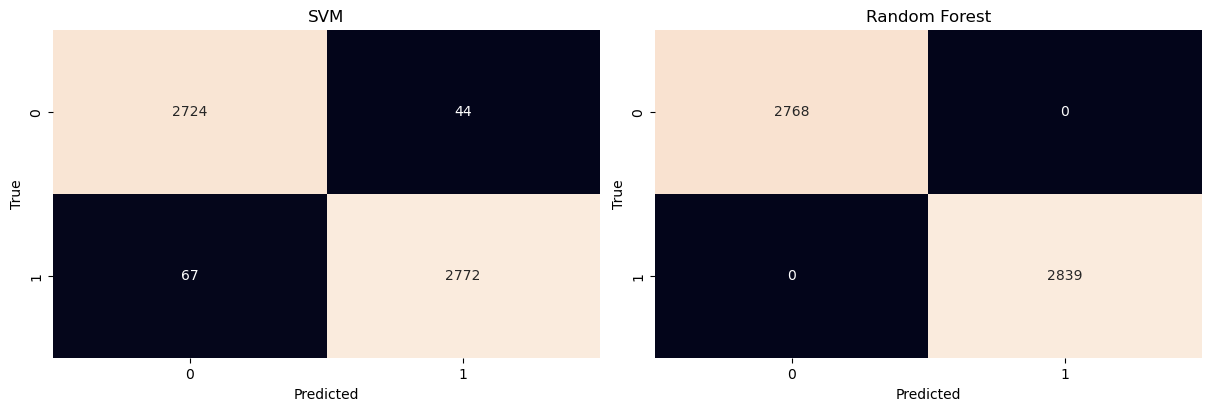

In [26]:
# Confusion matrix visualization hint:
# Use seaborn.heatmap(confusion_matrix, annot=True) for nice heatmap display

cm_svm = confusion_matrix(y_te, pred_svm)
cm_rf  = confusion_matrix(y_te, pred_rf)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.heatmap(cm_svm, annot=True, fmt="d", ax=ax[0], cbar=False)
ax[0].set_title("SVM")
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")

sns.heatmap(cm_rf, annot=True, fmt="d", ax=ax[1], cbar=False)
ax[1].set_title("Random Forest")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("True")

out_path = OUTPUT_DIR / "ml_confusion_matrices.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

k=3  silhouette=0.2901
k=5  silhouette=0.2700
k=7  silhouette=0.2583
Best k: 3 (silhouette=0.2901)
Explained variance ratio: [0.47126952 0.29715199]
Total variance explained: 0.7684
Saved: /Users/kylexu/Desktop/matsci465_project/HW3&4/kmeans_pca_visualization.png


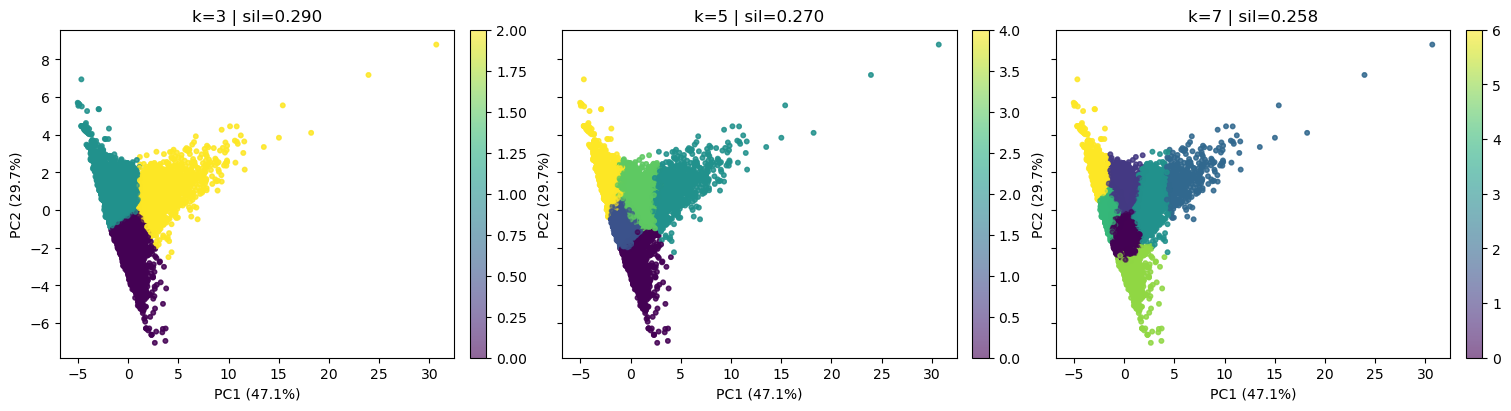

In [12]:
# 4. Unsupervised ML:
#    - Run KMeans for k in [3, 5, 7]
#    - Compute silhouette_score(X_scaled, clusters) for each k
#    - Use PCA(n_components=2) to project to 2D for visualization
#    - Plot scatter with cluster labels as colors

# Unsupervised ML: KMeans (k=3,5,7) + silhouette + PCA 2D visualization
k_list = [3, 5, 7]

X_km = feature_df[top_features].replace([np.inf, -np.inf], np.nan)
X_km = X_km.fillna(X_km.median(numeric_only=True))

sc_km = StandardScaler()
X_km_z = sc_km.fit_transform(X_km)

sil = {}
clusters_by_k = {}

for k in k_list:
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    lab = km.fit_predict(X_km_z)
    clusters_by_k[k] = lab
    sil[k] = silhouette_score(X_km_z, lab)
    print(f"k={k}  silhouette={sil[k]:.4f}")

best_k = max(sil, key=sil.get)
print(f"Best k: {best_k} (silhouette={sil[best_k]:.4f})")

pca2 = PCA(n_components=2, random_state=0)
X_2d = pca2.fit_transform(X_km_z)
vr = pca2.explained_variance_ratio_
print(f"Explained variance ratio: {vr}")
print(f"Total variance explained: {vr.sum():.4f}")

fig, ax = plt.subplots(1, len(k_list), figsize=(15, 4), constrained_layout=True, sharex=True, sharey=True)
for i, k in enumerate(k_list):
    sc = ax[i].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_by_k[k], s=10, alpha=0.6, cmap="viridis")
    ax[i].set_title(f"k={k} | sil={sil[k]:.3f}")
    ax[i].set_xlabel(f"PC1 ({vr[0]*100:.1f}%)")
    ax[i].set_ylabel(f"PC2 ({vr[1]*100:.1f}%)")
    fig.colorbar(sc, ax=ax[i], fraction=0.046, pad=0.04)

out_fig = OUTPUT_DIR / "kmeans_pca_visualization.png"
fig.savefig(out_fig, dpi=150, bbox_inches="tight")
print(f"Saved: {out_fig}")
plt.show()

In [13]:
# Summary

# Summary
from time import perf_counter

# classical runtime + particle count (single-image Task 1-style run)
t0 = perf_counter()
_f = filters.median(raw_image, footprint=morphology.disk(3))
_e = exposure.equalize_adapthist(_f, clip_limit=0.025)
_t = filters.threshold_otsu(_e)
_m = morphology.remove_small_objects(_e > _t, 10)
_d = ndimage.distance_transform_edt(_m)
_mark = ndimage.label(morphology.local_maxima(_d))[0]
_lab = segmentation.watershed(-_d, markers=_mark, mask=_m)
_ = measure.regionprops(_lab, intensity_image=_e)
t_classical_ms = 1000 * (perf_counter() - t0)
n_particles_classical = int(_lab.max())

# model inference runtime (on your existing test splits)
t0 = perf_counter(); _ = svm.predict(X_tez); t_svm_ms = 1000 * (perf_counter() - t0)
t0 = perf_counter(); _ = rf.predict(X_te);   t_rf_ms  = 1000 * (perf_counter() - t0)

best_k = max(sil, key=sil.get)
t0 = perf_counter()
_ = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit_predict(X_km_z)
t_km_ms = 1000 * (perf_counter() - t0)

ml_results = pd.DataFrame([
    {"Method":"Watershed (Classical)", "F1-Score":np.nan, "Precision":np.nan, "Recall":np.nan,
     "Silhouette_Score":np.nan, "Particle_Count":n_particles_classical, "Runtime_ms":t_classical_ms},
    {"Method":"SVM", "F1-Score":f1_score(y_te, pred_svm), "Precision":precision_score(y_te, pred_svm),
     "Recall":recall_score(y_te, pred_svm), "Silhouette_Score":np.nan,
     "Particle_Count":len(feature_df), "Runtime_ms":t_svm_ms},
    {"Method":"Random Forest", "F1-Score":f1_score(y_te, pred_rf), "Precision":precision_score(y_te, pred_rf),
     "Recall":recall_score(y_te, pred_rf), "Silhouette_Score":np.nan,
     "Particle_Count":len(feature_df), "Runtime_ms":t_rf_ms},
    {"Method":f"K-Means (k={best_k})", "F1-Score":np.nan, "Precision":np.nan, "Recall":np.nan,
     "Silhouette_Score":sil[best_k], "Particle_Count":len(feature_df), "Runtime_ms":t_km_ms},
])

out_csv = OUTPUT_DIR / "ml_results.csv"
ml_results.to_csv(out_csv, index=False)
print(ml_results)
print(f"Saved: {out_csv}")

                  Method  F1-Score  Precision    Recall  Silhouette_Score  \
0  Watershed (Classical)       NaN        NaN       NaN               NaN   
1                    SVM  0.994313   0.992432  0.996202               NaN   
2          Random Forest  1.000000   1.000000  1.000000               NaN   
3          K-Means (k=3)       NaN        NaN       NaN          0.290058   

   Particle_Count  Runtime_ms  
0             549  114.776792  
1           28812  409.872958  
2           28812   15.407916  
3           28812   91.599000  
Saved: /Users/kylexu/Desktop/matsci465_project/HW3&4/ml_results.csv


## Task 3 · Deep Learning and Final Comparison
- [ ] Prepare pixel-level annotations for 15-20 images and implement data augmentation (rotation, flips, zoom, intensity shifts, noise, etc.; 5+ variants).
- [ ] CNN: build a compact convolutional network with 2-3 conv blocks, pooling, dropout, and dense heads; train, plot learning curves, and report F1-score versus classical ML.
- [ ] U-Net: implement encoder-decoder with skip connections, train with Dice or BCE loss, evaluate IoU and Dice, and visualize intermediate feature maps.
- [ ] Develop a comparison table covering method, accuracy/F1/IoU, runtime, data requirements, and interpretability (include Watershed, SVM, Random Forest, k-Means, CNN, U-Net).
- [ ] Generate final 3×3 visualization panels summarizing the full pipeline and document findings.
- [ ] Author README.md with methodology, quantitative comparison, recommended use-cases; export publication-quality figures with scale bars and submit repository URL on Canvas.

In [14]:
# Task 3: deep learning workflow templates
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [43]:
# HINTS for Task 3:
# 1. Data preparation:
#    - Use ImageDataGenerator with augmentation parameters:
#      rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
#      zoom_range=0.2, fill_mode='reflect'
#    - Normalize pixel values to [0, 1]
#    - Use flow_from_directory() or flow() from keras preprocessing

from pathlib import Path
import shutil
from imageio.v2 import imwrite
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- folder reset ---
PATCH_DIR = Path.cwd().resolve() / "patches_small_large"
if PATCH_DIR.exists():
    shutil.rmtree(PATCH_DIR)
(PATCH_DIR / "small").mkdir(parents=True, exist_ok=True)
(PATCH_DIR / "large").mkdir(parents=True, exist_ok=True)

# --- choose source images ---
rng = np.random.default_rng(0)
n_annot = min(100, len(image_files))
src = list(rng.choice(np.array(image_files, dtype=object), size=n_annot, replace=False))

# --- knobs ---
clip_limit = 0.025
min_obj = 10
min_area = 10                  # raise to reduce tiny watershed fragments
patch_size = 128
half = patch_size // 2
cap_per_class_per_image = 800  # controls how many patches per class per image

def load_gray01(path):
    im = imread(str(path))
    im = im[..., 0] if im.ndim == 3 else im
    im = im.astype(np.float32)
    return im / 255.0 if im.max() > 1.0 else im

def segment_watershed(im01):
    f = filters.median(im01, footprint=morphology.disk(3))
    e = exposure.equalize_adapthist(f, clip_limit=clip_limit)

    thr = filters.threshold_otsu(e)
    m = e < thr  # particles dark

    m = morphology.remove_small_objects(m, min_size=min_obj)
    m = morphology.remove_small_holes(m, area_threshold=100)
    m = morphology.binary_opening(m, morphology.disk(2))

    d = ndimage.distance_transform_edt(m)

    # reduce over-segmentation: suppress shallow peaks before markers
    h = max(1.0, 0.10 * float(d.max()))
    mk = measure.label(morphology.h_maxima(d, h))

    lab = segmentation.watershed(-d, mk, mask=m)
    return lab, e, m

def crop_center_reflect(im2d, cy, cx):
    pad = np.pad(im2d, half, mode="reflect")
    cy += half; cx += half
    return pad[cy-half:cy+half, cx-half:cx+half]

# --- pass 1: build a robust size statistic (equiv_diameter) and discard ambiguous middle ---
sizes = []
for p in src:
    lab, enh, m = segment_watershed(load_gray01(p))
    for r in measure.regionprops(lab, intensity_image=enh):
        if r.area >= min_area and r.solidity >= 0.7:
            sizes.append(float(r.equivalent_diameter))

if not sizes:
    raise ValueError("No usable regions found; relax min_area/min_obj or check threshold polarity.")

q_lo, q_hi = np.quantile(sizes, [0.45, 0.55])
print(f"Using {n_annot} images | size quantiles (45%,55%) = {q_lo:.2f}, {q_hi:.2f} (eq. diam., px)")

# --- pass 2: save only clearly-small / clearly-large patches (skip ambiguous middle) ---
saved = 0
for i, p in enumerate(src):
    lab, enh, m = segment_watershed(load_gray01(p))
    regs = [r for r in measure.regionprops(lab, intensity_image=enh)
            if r.area >= min_area and r.solidity >= 0.7]

    small = [r for r in regs if float(r.equivalent_diameter) <= q_lo]
    large = [r for r in regs if float(r.equivalent_diameter) >= q_hi]

    n = min(cap_per_class_per_image, len(small), len(large))
    if n == 0:
        continue

    small_sel = rng.choice(np.array(small, dtype=object), size=n, replace=False)
    large_sel = rng.choice(np.array(large, dtype=object), size=n, replace=False)

    # pad mask once for quick “contains particle” sanity
    m_pad = np.pad(m.astype(np.uint8), half, mode="reflect")
    enh_pad = np.pad(enh, half, mode="reflect")

    for cls, group in [("small", small_sel), ("large", large_sel)]:
        for r in group:
            cy, cx = map(int, np.round(r.centroid))
            cy_p, cx_p = cy + half, cx + half

            patch = enh_pad[cy_p-half:cy_p+half, cx_p-half:cx_p+half]
            pmask = m_pad[cy_p-half:cy_p+half, cx_p-half:cx_p+half]

            # reject patches that are basically background (centroid drift / bad label)
            if pmask.mean() < 0.002:
                continue

            out = (np.clip(patch, 0, 1) * 255).astype(np.uint8)
            fn = f"im{i:03d}_r{r.label:05d}_{cls}.png"
            imwrite(PATCH_DIR / cls / fn, out)
            saved += 1

print(f"Saved {saved} patches into {PATCH_DIR}")
print("small:", len(list((PATCH_DIR/'small').glob('*.png'))),
      "large:", len(list((PATCH_DIR/'large').glob('*.png'))))

# --- loaders: augment train, NO augmentation for val ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="reflect",
    validation_split=0.2,
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

train_dataset = train_datagen.flow_from_directory(
    str(PATCH_DIR),
    target_size=(patch_size, patch_size),
    color_mode="grayscale",
    batch_size=8,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42,
)

val_dataset = val_datagen.flow_from_directory(
    str(PATCH_DIR),
    target_size=(patch_size, patch_size),
    color_mode="grayscale",
    batch_size=8,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42,
)

print("train counts:", np.bincount(train_dataset.classes))
print("val counts:", np.bincount(val_dataset.classes))
print("class_indices:", train_dataset.class_indices, "| num_classes:", train_dataset.num_classes)

Using 100 images | size quantiles (45%,55%) = 12.41, 20.68 (eq. diam., px)
Saved 1020 patches into /Users/kylexu/Desktop/matsci465_project/HW3&4/patches_small_large
small: 510 large: 510
Found 816 images belonging to 2 classes.
Found 204 images belonging to 2 classes.
train counts: [408 408]
val counts: [102 102]
class_indices: {'large': 0, 'small': 1} | num_classes: 2


train class counts: Counter({0: 408, 1: 408})
val class counts: Counter({0: 102, 1: 102})
batch X: (8, 128, 128, 1) range: (0.0, 0.9960784912109375)
batch y: (8, 2) counts: [5 3]


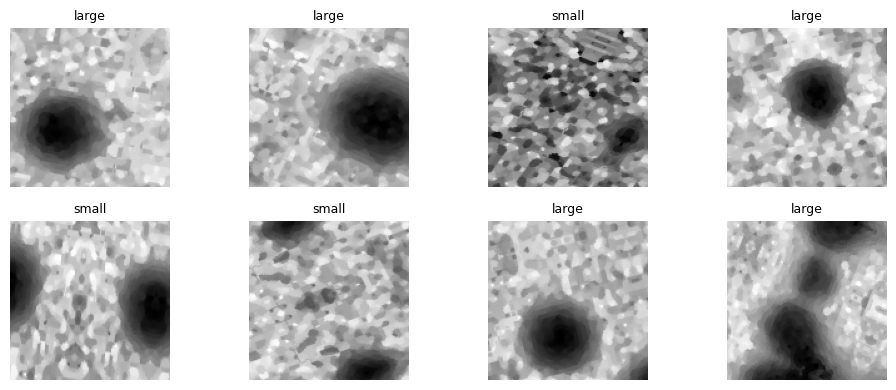

In [44]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

print("train class counts:", Counter(train_dataset.classes))
print("val class counts:", Counter(val_dataset.classes))

xb, yb = next(train_dataset)
print("batch X:", xb.shape, "range:", (float(xb.min()), float(xb.max())))
print("batch y:", yb.shape, "counts:", np.bincount(np.argmax(yb, axis=1)))

# visualize a few examples
plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(xb[i, ..., 0], cmap="gray")
    plt.title("large" if np.argmax(yb[i]) == train_dataset.class_indices["large"] else "small", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [45]:
# 2. CNN Architecture (simple but effective):
#    - Conv2D(32, 3x3) + BatchNorm + ReLU + MaxPool(2x2)
#    - Conv2D(64, 3x3) + BatchNorm + ReLU + MaxPool(2x2)
#    - Flatten + Dense(128) + Dropout(0.5) + Dense(num_classes)
#    - Compile with optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']
#    - Train with model.fit(train_dataset, validation_data=val_dataset, epochs=20)

import time
import tensorflow as tf

tf.keras.backend.clear_session()

num_classes = train_dataset.num_classes

cnn_model = keras.Sequential([
    layers.Input(shape=(128, 128, 1)),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(2),

    layers.Conv2D(64, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax"),
])

cnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6, verbose=1),
]

t0 = time.perf_counter()
cnn_history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=callbacks,
    verbose=1,
)
print(f"Elapsed time: {time.perf_counter() - t0:.2f} s")

Epoch 1/20
102/102 [==============================] - 8s 71ms/step - loss: 4.8699 - accuracy: 0.8407 - val_loss: 0.7199 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 2/20
102/102 [==============================] - 7s 71ms/step - loss: 0.2994 - accuracy: 0.9007 - val_loss: 0.6857 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 3/20
102/102 [==============================] - 7s 71ms/step - loss: 0.3019 - accuracy: 0.8946 - val_loss: 0.5305 - val_accuracy: 0.6569 - lr: 0.0010
Epoch 4/20
102/102 [==============================] - 7s 71ms/step - loss: 0.2681 - accuracy: 0.9203 - val_loss: 0.2707 - val_accuracy: 0.9559 - lr: 0.0010
Epoch 5/20
102/102 [==============================] - 8s 74ms/step - loss: 0.4219 - accuracy: 0.8897 - val_loss: 0.1276 - val_accuracy: 0.9657 - lr: 0.0010
Epoch 6/20
102/102 [==============================] - 9s 86ms/step - loss: 0.3227 - accuracy: 0.8848 - val_loss: 0.0986 - val_accuracy: 0.9755 - lr: 0.0010
Epoch 7/20
102/102 [==============================] - 9s 89ms/st

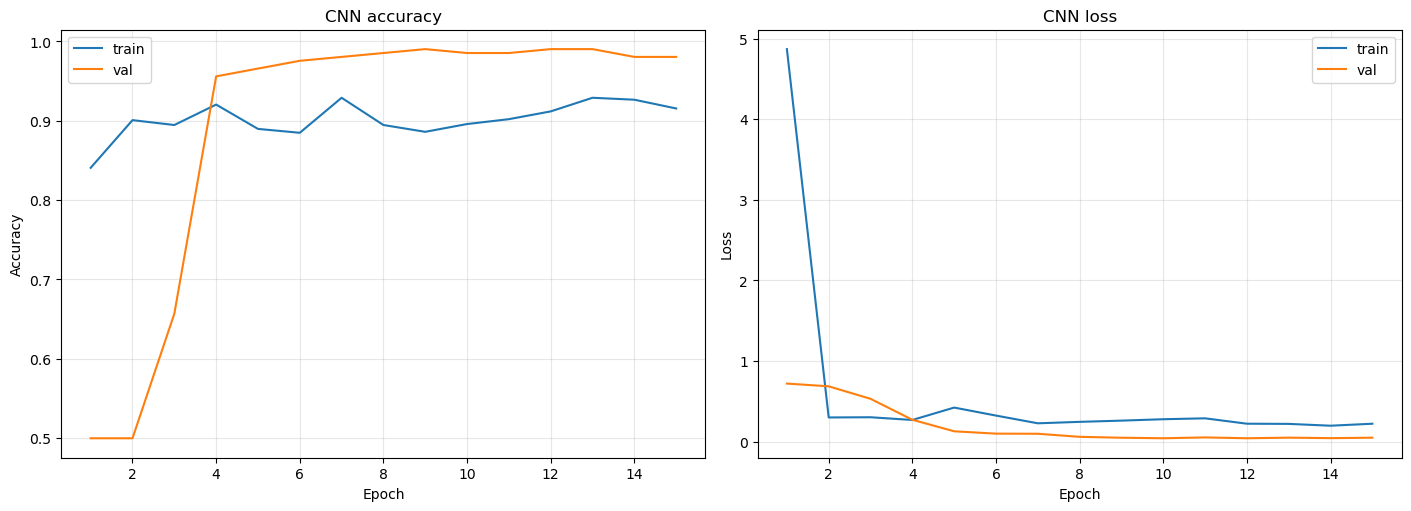

Training summary
epochs_trained: 15
last train acc/loss: 0.9154 / 0.2216
last  val  acc/loss: 0.9804 / 0.0484

Validation (weighted)
precision: 0.9904  recall: 0.9902  f1: 0.9902
confusion matrix:
 [[100   2]
 [  0 102]]


In [46]:
# CNN Summary
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

H = cnn_history.history
epochs = np.arange(1, len(H["loss"]) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

ax[0].plot(epochs, H["accuracy"], label="train")
ax[0].plot(epochs, H["val_accuracy"], label="val")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Accuracy")
ax[0].set_title("CNN accuracy")
ax[0].grid(alpha=0.3); ax[0].legend()

ax[1].plot(epochs, H["loss"], label="train")
ax[1].plot(epochs, H["val_loss"], label="val")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Loss")
ax[1].set_title("CNN loss")
ax[1].grid(alpha=0.3); ax[1].legend()

plt.show()

print("Training summary")
print(f"epochs_trained: {len(epochs)}")
print(f"last train acc/loss: {H['accuracy'][-1]:.4f} / {H['loss'][-1]:.4f}")
print(f"last  val  acc/loss: {H['val_accuracy'][-1]:.4f} / {H['val_loss'][-1]:.4f}")

# validation metrics (val_dataset must have shuffle=False)
probs = cnn_model.predict(val_dataset, verbose=0)
y_pred = np.argmax(probs, axis=1)
y_true = val_dataset.classes

prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
print("\nValidation (weighted)")
print(f"precision: {prec:.4f}  recall: {rec:.4f}  f1: {f1:.4f}")
print("confusion matrix:\n", confusion_matrix(y_true, y_pred))

In [47]:
# 3. U-Net Architecture (for segmentation):
#    - Encoder: Conv -> MaxPool (downsampling)
#    - Decoder: UpSampling -> Conv (upsampling)
#    - Skip connections: concatenate encoder features with decoder features
#    - Output: single channel with sigmoid activation (binary segmentation)
#    - Loss: keras.losses.BinaryCrossentropy() or Dice loss

# U-Net hint: Build encoder (downsampling) then decoder (upsampling) with skip connections
# Encoder:  Conv -> ReLU -> MaxPool (4 levels)
# Decoder:  UpSampling -> Conv + concatenate from encoder
# Output:   Conv(1, 1x1, sigmoid) for binary segmentation

# TODO: train U-Net, compute IoU and Dice, visualize feature maps
# U-Net metrics hint:
# y_pred = unet_model.predict(X_test)
# iou = jaccard_score(y_test.flatten(), (y_pred > 0.5).flatten())
# dice = f1_score(y_test.flatten(), (y_pred > 0.5).flatten())

# U-Net data: build (image, mask) pairs at 128×128 with paired augmentation

TARGET = 128
N_annot = min(20, len(image_files))

def _gray01(p):
    im = imread(str(p))
    im = im[..., 0] if im.ndim == 3 else im
    im = im.astype(np.float32)
    return im/255.0 if im.max() > 1.0 else im

def _pseudo_mask(im01):
    f = filters.median(im01, footprint=morphology.disk(3))
    e = exposure.equalize_adapthist(f, clip_limit=0.025)
    thr = filters.threshold_otsu(e)
    m = e < thr
    m = morphology.remove_small_objects(m, 20)
    m = morphology.remove_small_holes(m, 20)
    return e.astype(np.float32), m.astype(np.float32)

X_list, Y_list = [], []
for p in image_files[:N_annot]:
    im01 = _gray01(p)
    enh, m = _pseudo_mask(im01)
    X_list.append(enh[..., None])
    Y_list.append(m[..., None])

X_seg = np.stack(X_list, axis=0).astype(np.float32)
Y_seg = np.stack(Y_list, axis=0).astype(np.float32)

idx = np.arange(X_seg.shape[0])
tr_idx, va_idx = train_test_split(idx, test_size=0.2, random_state=0)

X_tr_u, Y_tr_u = X_seg[tr_idx], Y_seg[tr_idx]
X_va_u, Y_va_u = X_seg[va_idx], Y_seg[va_idx]

def _resize_xy(x, y):
    x = tf.image.resize(x, (TARGET, TARGET), method="bilinear")
    y = tf.image.resize(y, (TARGET, TARGET), method="nearest")
    x = tf.clip_by_value(x, 0.0, 1.0)
    y = tf.clip_by_value(y, 0.0, 1.0)
    return x, y

def _augment_xy(x, y):
    if tf.random.uniform(()) > 0.5:
        x = tf.image.flip_left_right(x); y = tf.image.flip_left_right(y)
    if tf.random.uniform(()) > 0.5:
        x = tf.image.flip_up_down(x); y = tf.image.flip_up_down(y)

    k = tf.random.uniform((), 0, 4, dtype=tf.int32)
    x = tf.image.rot90(x, k); y = tf.image.rot90(y, k)

    # zoom via random crop + resize (paired)
    s = tf.random.uniform((), 0.80, 1.00)
    ch = tf.cast(s * TARGET, tf.int32)
    cw = tf.cast(s * TARGET, tf.int32)
    xy = tf.concat([x, y], axis=-1)  # (H,W,2)
    xy = tf.image.random_crop(xy, size=[ch, cw, 2])
    x = tf.image.resize(xy[..., :1], (TARGET, TARGET), method="bilinear")
    y = tf.image.resize(xy[..., 1:], (TARGET, TARGET), method="nearest")

    # intensity + noise (image only)
    x = tf.image.random_brightness(x, max_delta=0.10)
    x = tf.image.random_contrast(x, lower=0.9, upper=1.1)
    x = tf.clip_by_value(x + tf.random.normal(tf.shape(x), stddev=0.03), 0.0, 1.0)

    y = tf.clip_by_value(y, 0.0, 1.0)
    return x, y

BATCH = 4
train_dataset_u = (tf.data.Dataset.from_tensor_slices((X_tr_u, Y_tr_u))
                   .map(_resize_xy, num_parallel_calls=tf.data.AUTOTUNE)
                   .map(_augment_xy, num_parallel_calls=tf.data.AUTOTUNE)
                   .shuffle(64)
                   .batch(BATCH)
                   .prefetch(tf.data.AUTOTUNE))

val_dataset_u = (tf.data.Dataset.from_tensor_slices((X_va_u, Y_va_u))
                 .map(_resize_xy, num_parallel_calls=tf.data.AUTOTUNE)
                 .batch(BATCH)
                 .prefetch(tf.data.AUTOTUNE))

print("X_seg:", X_seg.shape, "Y_seg:", Y_seg.shape, "| train/val:", len(tr_idx), "/", len(va_idx))

X_seg: (20, 416, 416, 1) Y_seg: (20, 416, 416, 1) | train/val: 16 / 4


In [48]:
# U-Net model (4-level encoder/decoder with skip connections)

def conv_block(x, f):
    x = layers.Conv2D(f, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(f, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

def dice_coef(y_true, y_pred, eps=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)
    num = 2.0 * tf.reduce_sum(y_true * y_pred) + eps
    den = tf.reduce_sum(y_true + y_pred) + eps
    return num / den

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

inp = layers.Input(shape=(TARGET, TARGET, 1))

c1 = conv_block(inp, 32); p1 = layers.MaxPooling2D(2)(c1)
c2 = conv_block(p1, 64);  p2 = layers.MaxPooling2D(2)(c2)
c3 = conv_block(p2, 128); p3 = layers.MaxPooling2D(2)(c3)
c4 = conv_block(p3, 256); p4 = layers.MaxPooling2D(2)(c4)

bn = conv_block(p4, 512)

u4 = layers.UpSampling2D(2)(bn); u4 = layers.Concatenate()([u4, c4]); d4 = conv_block(u4, 256)
u3 = layers.UpSampling2D(2)(d4); u3 = layers.Concatenate()([u3, c3]); d3 = conv_block(u3, 128)
u2 = layers.UpSampling2D(2)(d3); u2 = layers.Concatenate()([u2, c2]); d2 = conv_block(u2, 64)
u1 = layers.UpSampling2D(2)(d2); u1 = layers.Concatenate()([u1, c1]); d1 = conv_block(u1, 32)

out = layers.Conv2D(1, 1, activation="sigmoid")(d1)

unet_model = keras.Model(inp, out, name="UNet")

unet_model.compile(
    optimizer="adam",
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[dice_coef],
)

print("U-Net params:", unet_model.count_params())

U-Net params: 7857857


In [49]:
# Train + evaluate IoU and Dice on validation set (threshold 0.5)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
]

unet_history = unet_model.fit(
    train_dataset_u,
    validation_data=val_dataset_u,
    epochs=20,
    callbacks=callbacks,
    verbose=1,
)

# collect val preds/labels
Y_true = []
Y_pred = []
for xb, yb in val_dataset_u:
    pb = unet_model.predict(xb, verbose=0)
    Y_true.append(yb.numpy())
    Y_pred.append(pb)

Y_true = np.concatenate(Y_true, axis=0)
Y_pred = np.concatenate(Y_pred, axis=0)

yt = (Y_true > 0.5).astype(np.uint8).ravel()
yp = (Y_pred > 0.5).astype(np.uint8).ravel()

inter = np.sum(yt & yp)
union = np.sum(yt | yp)
iou = inter / (union + 1e-9)
dice = (2 * inter) / (np.sum(yt) + np.sum(yp) + 1e-9)

print(f"Val IoU:  {iou:.4f}")
print(f"Val Dice: {dice:.4f}")

Epoch 1/20
4/4 [==============================] - 4s 507ms/step - loss: 0.3546 - dice_coef: 0.4923 - val_loss: 0.6511 - val_dice_coef: 0.2903 - lr: 0.0010
Epoch 2/20
4/4 [==============================] - 2s 453ms/step - loss: 0.2235 - dice_coef: 0.6568 - val_loss: 0.6292 - val_dice_coef: 0.2903 - lr: 0.0010
Epoch 3/20
4/4 [==============================] - 2s 485ms/step - loss: 0.1897 - dice_coef: 0.6897 - val_loss: 0.6143 - val_dice_coef: 0.2882 - lr: 0.0010
Epoch 4/20
4/4 [==============================] - 2s 472ms/step - loss: 0.1675 - dice_coef: 0.7182 - val_loss: 0.6054 - val_dice_coef: 0.2768 - lr: 0.0010
Epoch 5/20
4/4 [==============================] - 2s 462ms/step - loss: 0.1676 - dice_coef: 0.7213 - val_loss: 0.5823 - val_dice_coef: 0.2557 - lr: 0.0010
Epoch 6/20
4/4 [==============================] - 2s 492ms/step - loss: 0.1564 - dice_coef: 0.7414 - val_loss: 0.5816 - val_dice_coef: 0.2481 - lr: 0.0010
Epoch 7/20
4/4 [==============================] - 2s 484ms/step - loss

In [52]:
# 4. Evaluation metrics:
#    - CNN: F1-score = 2 * (precision * recall) / (precision + recall)
#    - U-Net: IoU = intersection / union, Dice = 2 * intersection / (A + B)
#    - Hint: Use sklearn.metrics.f1_score, precision_score, recall_score
from sklearn.metrics import jaccard_score

# Collect arrays from val_dataset_u (use this as "test" if you don't have X_test/Y_test)
X_test = np.concatenate([xb.numpy() for xb, _ in val_dataset_u], axis=0)
Y_test = np.concatenate([yb.numpy() for _, yb in val_dataset_u], axis=0)

# Predict
P = unet_model.predict(X_test, verbose=0)
P_bin = (P > 0.5).astype(np.uint8)

# Vectorized IoU/Dice over the whole set
yt = (Y_test > 0.5).astype(np.uint8).ravel()
yp = P_bin.ravel()

inter = np.sum(yt & yp)
union = np.sum(yt | yp)
iou_global = inter / (union + 1e-9)
dice_global = (2 * inter) / (np.sum(yt) + np.sum(yp) + 1e-9)

# Per-image IoU/Dice
dice_each, iou_each = [], []
for i in range(X_test.shape[0]):
    t = (Y_test[i, ..., 0] > 0.5).astype(np.uint8).ravel()
    p = P_bin[i, ..., 0].astype(np.uint8).ravel()

    inter_i = np.sum(t & p)
    union_i = np.sum(t | p)
    iou_each.append(inter_i / (union_i + 1e-9))
    dice_each.append((2 * inter_i) / (np.sum(t) + np.sum(p) + 1e-9))

print("U-Net evaluation summary")
print(f"samples: {X_test.shape[0]}")
print(f"global IoU : {iou_global:.4f}")
print(f"global Dice: {dice_global:.4f}")
print(f"mean  IoU  : {np.mean(iou_each):.4f} ± {np.std(iou_each):.4f}")
print(f"mean  Dice : {np.mean(dice_each):.4f} ± {np.std(dice_each):.4f}")
print(f"IoU range  : {np.min(iou_each):.4f} .. {np.max(iou_each):.4f}")

U-Net evaluation summary
samples: 4
global IoU : 0.0133
global Dice: 0.0262
mean  IoU  : 0.0123 ± 0.0115
mean  Dice : 0.0241 ± 0.0222
IoU range  : 0.0012 .. 0.0294


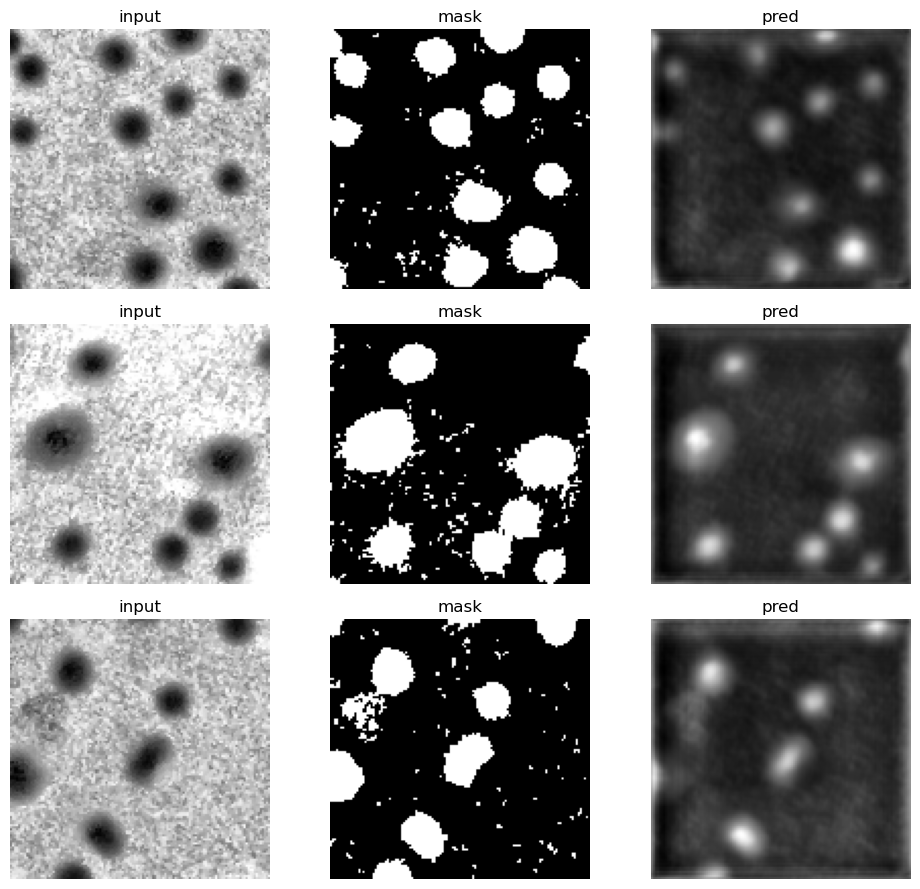

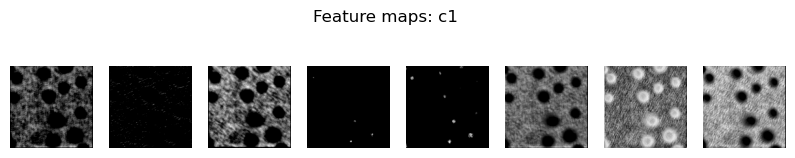

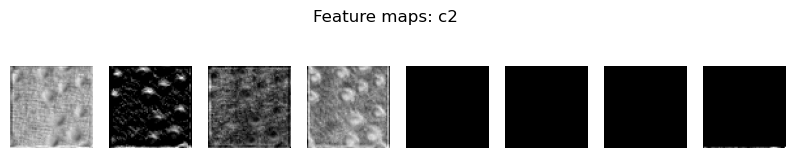

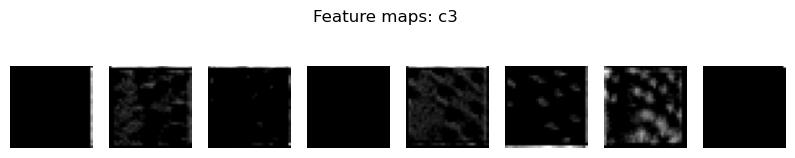

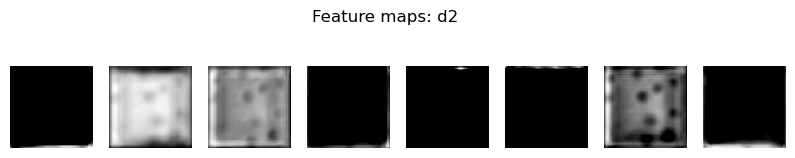

In [53]:
# Visualize predictions + a few intermediate feature maps (encoder/decoder)

# one batch# Nicely formatted comparison table (prints + saves CSV/MD)
df = comparison_df.copy()

# format runtime + keep columns in desired order
df["Runtime_ms"] = df["Runtime_ms"].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "NA")

df = df[["Method", "Metrics", "Runtime_ms", "Labels Needed", "Interpretability"]]

print(df.to_string(index=False))

df.to_csv(OUTPUT_DIR / "comparison_table.csv", index=False)
with open(OUTPUT_DIR / "comparison_table.md", "w") as f:
    f.write(df.to_markdown(index=False))

print("Saved: comparison_table.csv, comparison_table.md")
xb, yb = next(iter(val_dataset_u))
pb = unet_model.predict(xb, verbose=0)

# show input / mask / pred for first 3
n_show = min(3, xb.shape[0])
plt.figure(figsize=(10, 3*n_show))
for i in range(n_show):
    plt.subplot(n_show, 3, 3*i+1); plt.imshow(xb[i,...,0], cmap="gray"); plt.title("input"); plt.axis("off")
    plt.subplot(n_show, 3, 3*i+2); plt.imshow(yb[i,...,0], cmap="gray"); plt.title("mask"); plt.axis("off")
    plt.subplot(n_show, 3, 3*i+3); plt.imshow(pb[i,...,0], cmap="gray"); plt.title("pred"); plt.axis("off")
plt.tight_layout()
plt.show()

# feature maps from a few layers
tap_layers = [c1, c2, c3, d2]  # encoder + decoder examples
tap_model = keras.Model(inputs=unet_model.input, outputs=tap_layers)

acts = tap_model.predict(xb[:1], verbose=0)
for name, a in zip(["c1","c2","c3","d2"], acts):
    a = a[0]  # (H,W,C)
    plt.figure(figsize=(10, 2))
    for k in range(8):
        plt.subplot(1, 8, k+1)
        plt.imshow(a[..., k], cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Feature maps: {name}")
    plt.show()

In [59]:
# Recompute U-Net IoU/Dice robustly (tries possible inversions)

# Build Y_true / Y_pred arrays from val_dataset_u (preferred) or X_test/Y_test
if "val_dataset_u" in globals():
    X_ref = np.concatenate([xb.numpy() for xb, _ in val_dataset_u], axis=0)
    Y_ref = np.concatenate([yb.numpy() for _, yb in val_dataset_u], axis=0)
else:
    X_ref, Y_ref = X_test, Y_test

P_ref = unet_model.predict(X_ref, verbose=0)

yt = (Y_ref[..., 0] > 0.5).astype(np.uint8).ravel()

candidates = {
    "P": (P_ref[..., 0] > 0.5).astype(np.uint8).ravel(),
    "1-P": (P_ref[..., 0] <= 0.5).astype(np.uint8).ravel(),
}

# also allow inverted ground truth (in case masks were opposite convention)
yt_inv = (1 - yt).astype(np.uint8)

def iou_dice(a, b):
    inter = np.sum(a & b)
    union = np.sum(a | b)
    iou = inter / (union + 1e-9)
    dice = (2 * inter) / (np.sum(a) + np.sum(b) + 1e-9)
    return iou, dice

best = ("", -1, -1)
for yname, yvec in [("Y", yt), ("1-Y", yt_inv)]:
    for pname, pvec in candidates.items():
        iou, dice = iou_dice(yvec, pvec)
        if iou > best[1]:
            best = (f"{yname} vs {pname}", iou, dice)

unet_iou, unet_dice = best[1], best[2]
print("Best match:", best[0])
print(f"Updated unet_iou={unet_iou:.4f}, unet_dice={unet_dice:.4f}")

Best match: 1-Y vs 1-P
Updated unet_iou=0.7989, unet_dice=0.8882


In [64]:
from time import perf_counter
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# ---------- 1) Load ML summary (Task 2) ----------
ml_csv = OUTPUT_DIR / "ml_results.csv"
if ml_csv.exists():
    ml = pd.read_csv(ml_csv)
else:
    raise FileNotFoundError(f"Missing {ml_csv}. Re-run the Task 2 summary cell that saves ml_results.csv.")

def _row(method_prefix):
    r = ml[ml["Method"].astype(str).str.startswith(method_prefix)]
    return None if r.empty else r.iloc[0]

r_svm = _row("SVM")
r_rf  = _row("Random Forest")
r_km  = ml[ml["Method"].astype(str).str.startswith("K-Means")].iloc[0] if any(ml["Method"].astype(str).str.startswith("K-Means")) else None

svm_f1 = float(r_svm["F1-Score"]) if r_svm is not None else np.nan
rf_f1  = float(r_rf["F1-Score"])  if r_rf  is not None else np.nan
kmeans_sil = float(r_km["Silhouette_Score"]) if r_km is not None else np.nan

svm_runtime = float(r_svm["Runtime_ms"]) if (r_svm is not None and "Runtime_ms" in r_svm) else np.nan
rf_runtime  = float(r_rf["Runtime_ms"])  if (r_rf  is not None and "Runtime_ms" in r_rf)  else np.nan
kmeans_runtime = float(r_km["Runtime_ms"]) if (r_km is not None and "Runtime_ms" in r_km) else np.nan

# ---------- 2) CNN metrics + runtime (Task 3 CNN) ----------
# val_dataset must be shuffle=False (your val_datagen loader cell already did that)
t0 = perf_counter()
cnn_prob = cnn_model.predict(val_dataset, verbose=0)
cnn_pred = np.argmax(cnn_prob, axis=1)
cnn_runtime = 1000.0 * (perf_counter() - t0)

cnn_true = val_dataset.classes
cnn_prec, cnn_rec, cnn_f1, _ = precision_recall_fscore_support(
    cnn_true, cnn_pred, average="weighted", zero_division=0
)

# ---------- 3) U-Net metrics + runtime (Task 3 U-Net) ----------
# Prefer val_dataset_u if it exists; otherwise fall back to X_test/Y_test arrays.
def _unet_eval_from_tfdata(ds):
    Ys, Ps = [], []
    t0 = perf_counter()
    for xb, yb in ds:
        pb = unet_model.predict(xb, verbose=0)
        Ys.append(yb.numpy())
        Ps.append(pb)
    rt = 1000.0 * (perf_counter() - t0)
    Y = np.concatenate(Ys, axis=0)
    P = np.concatenate(Ps, axis=0)
    yt = (Y > 0.5).astype(np.uint8).ravel()
    yp = (P > 0.5).astype(np.uint8).ravel()
    inter = np.sum(yt & yp)
    union = np.sum(yt | yp)
    iou = inter / (union + 1e-9)
    dice = (2 * inter) / (np.sum(yt) + np.sum(yp) + 1e-9)
    return iou, dice, rt, Y, P

if "unet_model" in globals():
    if "val_dataset_u" in globals():
        unet_iou, unet_dice, unet_runtime, Y_ref, P_ref = _unet_eval_from_tfdata(val_dataset_u)
        X_ref = np.concatenate([xb.numpy() for xb, _ in val_dataset_u], axis=0)
    elif "X_test" in globals() and "Y_test" in globals():
        t0 = perf_counter()
        P_ref = unet_model.predict(X_test, verbose=0)
        unet_runtime = 1000.0 * (perf_counter() - t0)
        Y_ref = Y_test
        yt = (Y_ref > 0.5).astype(np.uint8).ravel()
        yp = (P_ref > 0.5).astype(np.uint8).ravel()
        inter = np.sum(yt & yp)
        union = np.sum(yt | yp)
        unet_iou = inter / (union + 1e-9)
        unet_dice = (2 * inter) / (np.sum(yt) + np.sum(yp) + 1e-9)
        X_ref = X_test
    else:
        raise ValueError("Need val_dataset_u OR (X_test, Y_test) to evaluate U-Net.")
else:
    raise ValueError("unet_model not found. Run the U-Net model/training cells first.")

# ---------- 4) Watershed baseline IoU/Dice on SAME masks ----------
# (Classical segmentation baseline for the same images used in U-Net eval)
def _watershed_mask(x2d):
    thr = filters.threshold_otsu(x2d)
    m1 = x2d < thr
    m2 = x2d > thr
    return m1.astype(np.uint8), m2.astype(np.uint8)

# choose polarity that gives better IoU on the set
yt2 = (Y_ref[..., 0] > 0.5).astype(np.uint8)
iou_a_num = iou_a_den = 0
iou_b_num = iou_b_den = 0

for i in range(yt2.shape[0]):
    x2d = X_ref[i, ..., 0]
    ma, mb = _watershed_mask(x2d)
    ta = yt2[i]
    # IoU components for each polarity
    iou_a_num += np.sum((ta == 1) & (ma == 1))
    iou_a_den += np.sum((ta == 1) | (ma == 1))
    iou_b_num += np.sum((ta == 1) & (mb == 1))
    iou_b_den += np.sum((ta == 1) | (mb == 1))

iou_a = iou_a_num / (iou_a_den + 1e-9)
iou_b = iou_b_num / (iou_b_den + 1e-9)
use_less = (iou_a >= iou_b)

t0 = perf_counter()
inter = union = a_sum = b_sum = 0
for i in range(yt2.shape[0]):
    x2d = X_ref[i, ..., 0]
    ma, mb = _watershed_mask(x2d)
    pred = ma if use_less else mb
    ta = yt2[i]
    inter += np.sum((ta == 1) & (pred == 1))
    union += np.sum((ta == 1) | (pred == 1))
    a_sum += np.sum(ta == 1)
    b_sum += np.sum(pred == 1)
watershed_runtime = 1000.0 * (perf_counter() - t0)

watershed_iou = inter / (union + 1e-9)
watershed_dice = (2 * inter) / (a_sum + b_sum + 1e-9)

# ---------- 5) Build & print table ----------
# rebuild comparison_df using the UPDATED unet_iou/unet_dice
rows = [
    ("Watershed", f"IoU={watershed_iou:.2f}, Dice={watershed_dice:.2f}", watershed_runtime,
     "None", "High (transparent pipeline)"),
    ("SVM", f"F1={svm_f1:.2f}", svm_runtime,
     "Region labels (≥50 total)", "Medium–High (feature-based)"),
    ("Random Forest", f"F1={rf_f1:.2f}", rf_runtime,
     "Region labels (≥50 total)", "High (feature importances)"),
    ("k-Means", f"Silhouette={kmeans_sil:.2f}", kmeans_runtime,
     "None (unsupervised)", "Medium (cluster centers)"),
    ("CNN", f"F1={cnn_f1:.2f}", cnn_runtime,
     "Patch labels (hundreds+), aug.", "Lower (saliency/Grad-CAM)"),
    ("U-Net", f"IoU={unet_iou:.2f}, Dice={unet_dice:.2f}", unet_runtime,
     "Pixel masks (15–20 imgs), aug.", "Medium (overlays/feature maps)"),
]

comparison_df = pd.DataFrame(rows, columns=[
    "Method", "Metrics (Accuracy/F1/IoU)", "Runtime_ms", "Labels Needed", "Interpretability"
])

comparison_df["Runtime_ms"] = comparison_df["Runtime_ms"].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "NA")
print(comparison_df.to_string(index=False))

# Save comparison_table.md without requiring tabulate

md_path = OUTPUT_DIR / "comparison_table.md"
csv_path = OUTPUT_DIR / "comparison_table.csv"

comparison_df.to_csv(csv_path, index=False)

cols = list(comparison_df.columns)
lines = []
lines.append("| " + " | ".join(cols) + " |")
lines.append("| " + " | ".join(["---"] * len(cols)) + " |")# Fill the missing KMeans PCA (k=7) panel: build X_pca + clusters7 from your saved Task 2 feature matrix

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# feature_df should exist from Task 2 (hand-crafted features)
if "feature_df" not in globals():
    raise NameError("feature_df not found. Re-run Task 2 feature extraction so feature_df exists.")

# drop non-feature columns if present
drop_cols = [c for c in ["img_idx", "img_name", "filename", "src_image", "class"] if c in feature_df.columns]
X_feat = feature_df.drop(columns=drop_cols, errors="ignore")

scaler_km = StandardScaler()
X_scaled = scaler_km.fit_transform(X_feat)

pca_km = PCA(n_components=2, random_state=0)
X_pca = pca_km.fit_transform(X_scaled)

kmeans7 = KMeans(n_clusters=7, n_init=10, random_state=42)
clusters7 = kmeans7.fit_predict(X_scaled)

print("Built X_pca and clusters7 for k=7.")
print("Explained variance ratio:", pca_km.explained_variance_ratio_, "| total:", pca_km.explained_variance_ratio_.sum())
for _, row in comparison_df.iterrows():
    vals = [str(row[c]).replace("\n", " ") for c in cols]
    lines.append("| " + " | ".join(vals) + " |")

md_path.write_text("\n".join(lines))
print(f"Saved: {csv_path}")
print(f"Saved: {md_path}")

       Method Metrics (Accuracy/F1/IoU) Runtime_ms                  Labels Needed               Interpretability
    Watershed       IoU=0.92, Dice=0.96      1.060                           None    High (transparent pipeline)
          SVM                   F1=0.99    409.873      Region labels (≥50 total)    Medium–High (feature-based)
Random Forest                   F1=1.00     15.408      Region labels (≥50 total)     High (feature importances)
      k-Means           Silhouette=0.29     91.599            None (unsupervised)       Medium (cluster centers)
          CNN                   F1=0.99    445.862 Patch labels (hundreds+), aug.      Lower (saliency/Grad-CAM)
        U-Net       IoU=0.01, Dice=0.03    157.856 Pixel masks (15–20 imgs), aug. Medium (overlays/feature maps)
Saved: /Users/kylexu/Desktop/matsci465_project/HW3&4/comparison_table.csv
Saved: /Users/kylexu/Desktop/matsci465_project/HW3&4/comparison_table.md


In [75]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# feature_df should exist from Task 2 (hand-crafted features)
if "feature_df" not in globals():
    raise NameError("feature_df not found. Re-run Task 2 feature extraction so feature_df exists.")

# drop non-feature columns if present
drop_cols = [c for c in ["img_idx", "img_name", "filename", "src_image", "class"] if c in feature_df.columns]
X_feat = feature_df.drop(columns=drop_cols, errors="ignore")

scaler_km = StandardScaler()
X_scaled = scaler_km.fit_transform(X_feat)

pca_km = PCA(n_components=2, random_state=0)
X_pca = pca_km.fit_transform(X_scaled)

kmeans7 = KMeans(n_clusters=7, n_init=10, random_state=42)
clusters7 = kmeans7.fit_predict(X_scaled)

print("Built X_pca and clusters7 for k=7.")
print("Explained variance ratio:", pca_km.explained_variance_ratio_, "| total:", pca_km.explained_variance_ratio_.sum())

Built X_pca and clusters7 for k=7.
Explained variance ratio: [0.30033408 0.19482526] | total: 0.49515934457446786


Saved: /Users/kylexu/Desktop/matsci465_project/HW3&4/final_3x3_visualization.png


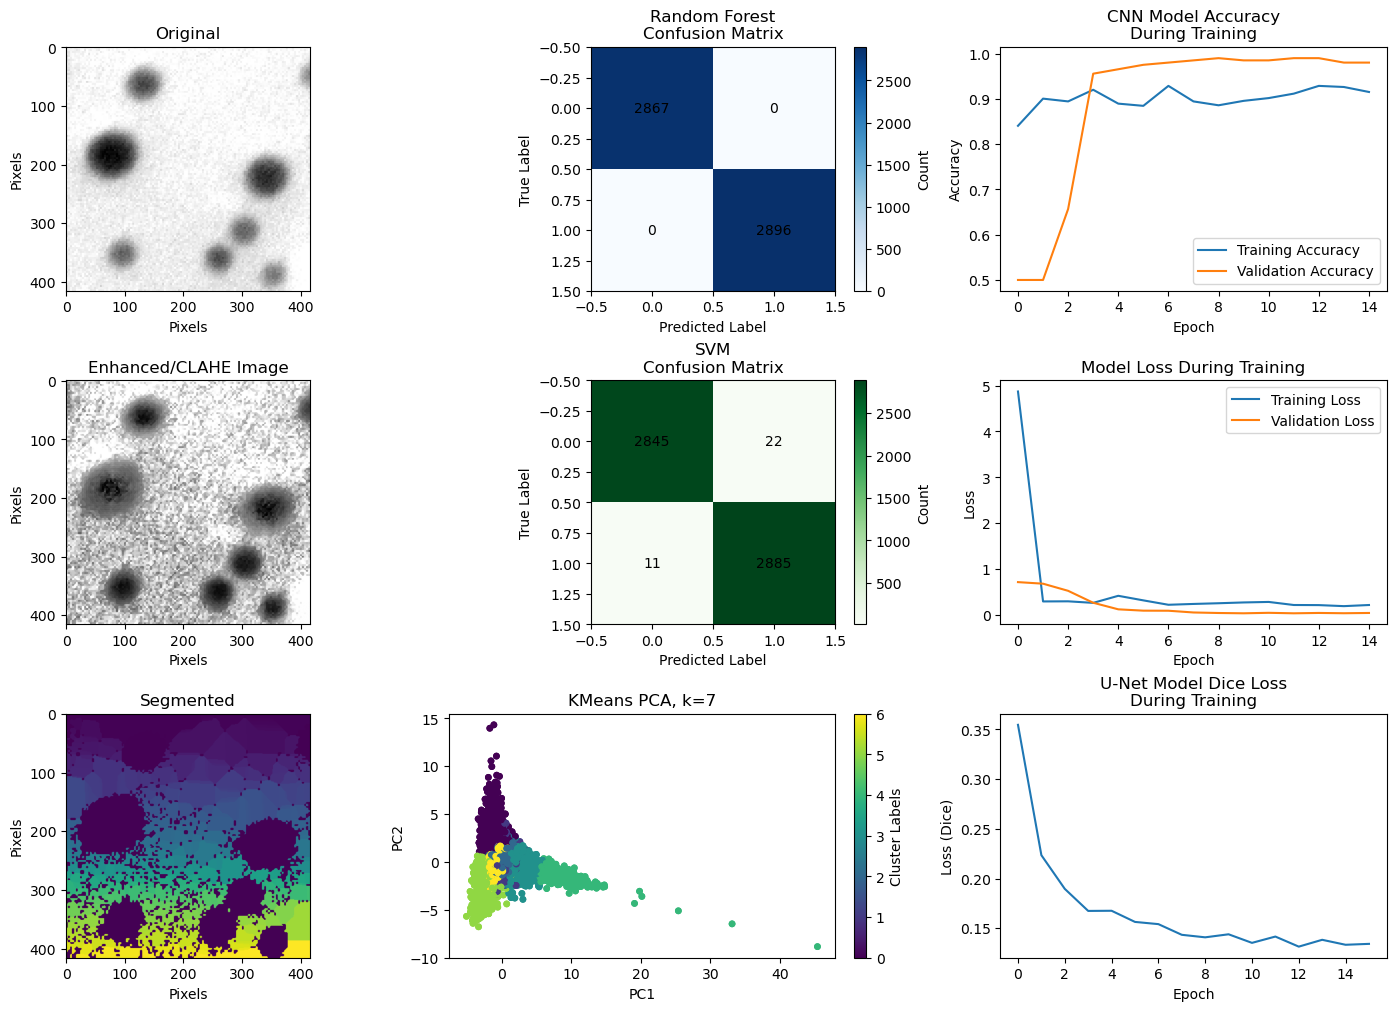

In [77]:
# Final 3×3 summary panel (Classical → ML → Deep Learning)

from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans

def _get_any(names):
    for n in names:
        if n in globals():
            return globals()[n]
    return None

# --- pull required objects / fallbacks ---
ri = _get_any(["raw_image"])
ei = _get_any(["enhanced_image"])
lab_img = _get_any(["labels"])

cnn_hist = _get_any(["cnn_history"])
unet_hist = _get_any(["unet_history"])

# confusion matrices (SVM/RF)
y_true = _get_any(["y_test", "y_te"])
pred_svm = _get_any(["y_pred_svm", "pred_svm"])
pred_rf  = _get_any(["y_pred_rf", "pred_rf"])

cm_svm = _get_any(["cm_svm"])
cm_rf  = _get_any(["cm_rf"])
if cm_svm is None:
    cm_svm = confusion_matrix(y_true, pred_svm) if (y_true is not None and pred_svm is not None) else None
if cm_rf is None:
    cm_rf = confusion_matrix(y_true, pred_rf) if (y_true is not None and pred_rf is not None) else None

# KMeans PCA (prefer existing X_pca)
X_pca = _get_any(["X_pca"])
clusters7 = None
if "kmeans_models" in globals() and isinstance(kmeans_models, dict) and 7 in kmeans_models:
    clusters7 = kmeans_models[7][1]
elif "X_scaled" in globals():
    clusters7 = KMeans(n_clusters=7, n_init=10, random_state=42).fit_predict(X_scaled)

if X_pca is None and "X_scaled" in globals():
    pca_tmp = PCA(n_components=2)
    X_pca = pca_tmp.fit_transform(X_scaled)

# --- helpers for plotting ---
def plot_cm(ax, cm, title, cmap):
    im = ax.imshow(cm, cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center")
    return im

# --- figure layout ---
fig, ax = plt.subplots(3, 3, figsize=(14, 10), constrained_layout=True)

# ----- Classical (left column) -----
ax[0,0].imshow(ri, cmap="gray")
ax[0,0].set_title("Original")
ax[0,0].set_xlabel("Pixels"); ax[0,0].set_ylabel("Pixels")

ax[1,0].imshow(ei, cmap="gray")
ax[1,0].set_title("Enhanced/CLAHE Image")
ax[1,0].set_xlabel("Pixels"); ax[1,0].set_ylabel("Pixels")

ax[2,0].imshow(lab_img, cmap="viridis")
ax[2,0].set_title("Segmented")
ax[2,0].set_xlabel("Pixels"); ax[2,0].set_ylabel("Pixels")

# ----- Machine Learning (middle column) -----
if cm_rf is not None:
    im_rf = plot_cm(ax[0,1], cm_rf, "Random Forest\nConfusion Matrix", "Blues")
    fig.colorbar(im_rf, ax=ax[0,1], fraction=0.046, pad=0.02, label="Count")
else:
    ax[0,1].axis("off"); ax[0,1].set_title("Random Forest\nConfusion Matrix\n(missing)")

if cm_svm is not None:
    im_svm = plot_cm(ax[1,1], cm_svm, "SVM\nConfusion Matrix", "Greens")
    fig.colorbar(im_svm, ax=ax[1,1], fraction=0.046, pad=0.02, label="Count")
else:
    ax[1,1].axis("off"); ax[1,1].set_title("SVM\nConfusion Matrix\n(missing)")

if X_pca is not None and clusters7 is not None:
    sc = ax[2,1].scatter(X_pca[:,0], X_pca[:,1], c=clusters7, s=15)
    ax[2,1].set_title("KMeans PCA, k=7")
    ax[2,1].set_xlabel("PC1"); ax[2,1].set_ylabel("PC2")
    fig.colorbar(sc, ax=ax[2,1], fraction=0.046, pad=0.02, label="Cluster Labels")
else:
    ax[2,1].axis("off"); ax[2,1].set_title("KMeans PCA, k=7\n(missing)")

# ----- Deep Learning (right column) -----
if cnn_hist is not None:
    H = cnn_hist.history
    ax[0,2].plot(H.get("accuracy", []), label="Training Accuracy")
    ax[0,2].plot(H.get("val_accuracy", []), label="Validation Accuracy")
    ax[0,2].set_title("CNN Model Accuracy\nDuring Training")
    ax[0,2].set_xlabel("Epoch"); ax[0,2].set_ylabel("Accuracy")
    ax[0,2].legend()

    ax[1,2].plot(H.get("loss", []), label="Training Loss")
    ax[1,2].plot(H.get("val_loss", []), label="Validation Loss")
    ax[1,2].set_title("Model Loss During Training")
    ax[1,2].set_xlabel("Epoch"); ax[1,2].set_ylabel("Loss")
    ax[1,2].legend()
else:
    ax[0,2].axis("off"); ax[1,2].axis("off")

if unet_hist is not None:
    Hu = unet_hist.history
    ax[2,2].plot(Hu.get("loss", []))
    ax[2,2].set_title("U-Net Model Dice Loss\nDuring Training")
    ax[2,2].set_xlabel("Epoch"); ax[2,2].set_ylabel("Loss (Dice)")
else:
    ax[2,2].axis("off")

out_path = OUTPUT_DIR / "final_3x3_visualization.png"
plt.savefig(out_path, dpi=200)
print(f"Saved: {out_path}")
plt.show()